<a href="https://colab.research.google.com/github/khanbaba-ahamaliiev/ITStep-AI/blob/superwised_learning/DZ_Overfitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Дані

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/ITStep-AI/refs/heads/superwised_learning/data/customer_spending.csv")

In [3]:
df.head()

,annual_income,account_tenure_days,age,engagement_score,support_tickets,annual_spending
0,57964.98,1170,65,35.95,5,218.46
1,27667.36,856,58,14.56,2,16.51
2,74068.69,1178,31,33.26,2,240.06
3,82232.89,741,33,87.93,2,242.77
4,16763.02,497,31,10.22,0,130.61


# Опис даних

Цу дані користувачів онлайн-сервісу **Shoply** — сайту, де люди купують товари та оформлюють підписки. Для кожного користувача зібрана інформація про його активність, дохід та взаємодію із сайтом.

* **annual_income** — скільки грошей користувач заробляє за рік
* **account_tenure_days** — скільки днів користувач зареєстрований на сайті
* **age** — вік користувача
* **engagement_score** — наскільки активно користувач користується сайтом
* **support_tickets** — скільки разів користувач звертався до служби підтримки
* **annual_spending** — скільки грошей користувач витрачає на сайті за рік


Потрібно спрогнозувати **витрати** користувача

# Завдання 1
Розділіть дані на ознаки для моделі(Х) та цільову змінну(y)

In [5]:
from sklearn.model_selection import train_test_split


y = df['annual_spending']
X = df.drop('annual_spending', axis=1)

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(5216, 5) (5216,)
(1304, 5) (1304,)


# Завдання 2
Розділіть дані на тренувальну та тестову вибірку

#Завдання 3
Нетренуйте дерево рішень на тренувальній вибірці

При створенні моделі використовуйте параметри за замовчуванням

In [6]:
from sklearn.tree import DecisionTreeRegressor


model = DecisionTreeRegressor()
model.fit(x_train, y_train)

DecisionTreeRegressor()

# Завдання 4
Спронозуйте витрати користувача для тренувальних даних та порівняйте зі справжніми

Використайте метрики MAE, MSE, R2

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
model.predict(x_test)

array([162.56, 116.4 , 137.7 , ..., 155.7 ,  80.08, 147.78])

In [8]:
pred = model.predict(x_test)

print("MAE: ", mean_absolute_error(y_test, pred))
print("MSE: ", mean_squared_error(y_test, pred))
print("R2: ", r2_score(y_test, pred))

MAE:  33.20633435582822
MSE:  1760.011604601227
R2:  0.5008485002253362


In [9]:

pred = model.predict(x_train)

print("MAE: ", mean_absolute_error(y_train, pred))
print("MSE: ", mean_squared_error(y_train, pred))
print("R2: ", r2_score(y_train, pred))

MAE:  0.0
MSE:  0.0
R2:  1.0


# Завдання 5
Спронозуйте витрати користувача для тестових даних та порівняйте зі справжніми

Використайте метрики MAE, MSE, R2

# Завдання 6
Для різних значень параметра `max_depth` натренуйте модель та порахуйте метрику `MAE` на тренувальних та тестових даних

Отримайте відповідно 2 списки -- `train_mae` та `test_mae`
візуалізуйте їх

In [12]:
train_mae = []
test_mae = []
max_depths = range(2,10)

for depth in max_depths:
    model = DecisionTreeRegressor(max_depth=depth)
    model.fit(x_train, y_train)

    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    train_mae.append(mean_absolute_error(y_train, train_pred))
    test_mae.append(mean_absolute_error(y_test, test_pred))
    print(f"Depth: {depth}, Train MAE: {train_mae[-1]}, Test MAE: {test_mae[-1]}")

Depth: 2, Train MAE: 31.6251986946527, Test MAE: 32.37055994240308
Depth: 3, Train MAE: 28.224786744448036, Test MAE: 28.151793095055726
Depth: 4, Train MAE: 25.784014724992403, Test MAE: 26.266120493435206
Depth: 5, Train MAE: 23.84374721400964, Test MAE: 23.861328317389244
Depth: 6, Train MAE: 22.670991151668908, Test MAE: 23.779905538946963
Depth: 7, Train MAE: 21.590362728677473, Test MAE: 24.030220151225507
Depth: 8, Train MAE: 20.594217460219273, Test MAE: 24.59104867957905
Depth: 9, Train MAE: 19.286970682279446, Test MAE: 25.027356247434312


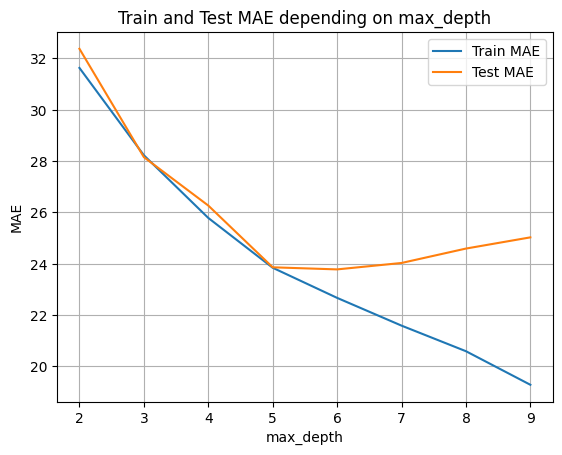

In [13]:
# код для візуалізації
# вам потрібно створити список max_depthes зі значеннями параметра який ви використовували
import matplotlib.pyplot as plt

plt.plot(max_depths, train_mae, label="Train MAE")
plt.plot(max_depths, test_mae, label="Test MAE")

plt.xlabel("max_depth")
plt.ylabel("MAE")
plt.title("Train and Test MAE depending on max_depth")
plt.legend()
plt.grid()

plt.show()

# Завдання 7
По графіку визначте оптимальне значення параметра `max_depth`

In [16]:
optimal_max_depth = max_depths[test_mae.index(min(test_mae))]
print(optimal_max_depth)

6
